# WMT16 德语 → 英语机器翻译 —— Transformer

本 Notebook 使用 PyTorch 完成 WMT16 德英新闻语料子集的神经机器翻译任务，采用经典 Transformer（Encoder-Decoder + 多头自注意力）架构。主要内容：

1. 文本预处理（Moses 分词 + SentencePiece 联合 BPE 子词编码）
2. 制作 Dataset（LangPairDataset 读取 BPE 句对并缓存）
3. Tokenizer 构建（共享词表 + BOS/EOS + 动态 Padding）
4. DataLoader 构建（按 Token 预算的动态批量采样与 collate_fn）
5. Transformer Embedding（词嵌入放缩 + 正弦位置编码）
6. 多头注意力机制（缩放点积注意力与 padding/因果掩码）
7. 前馈网络与编解码层（PositionwiseFeedForward / EncoderLayer / DecoderLayer）
8. 搭建 Transformer 总模型（Encoder-Decoder 与贪心自回归推理）
9. 编写损失函数（Label Smoothing 交叉熵）
10. Noam 优化器与学习率调度（预热 + 衰减）
11. 训练与评估
12. 翻译推理样例
13. BLEU 指标评估
14. 总结

数据目录：`data/wmt16/`（train/val/test 的 `.de` 与 `.en` 平行语料，约 2.9 万训练句对）。


## 1. 预处理 —— Moses 分词与 SentencePiece BPE 子词编码

对德英平行语料做两步预处理：先用 `sacremoses` 做 Moses 分词并转小写，再在训练集上联合训练 SentencePiece BPE（20000 子词，德英共享一套词表），最后对 train/val/test 做子词编码。


In [2]:
from pathlib import Path  # 路径工具，用于跨平台拼接数据文件路径

import sentencepiece as spm  # SentencePiece：训练与应用 BPE 子词模型
from sacremoses import MosesTokenizer  # Moses 分词器，机器翻译标准文本预处理工具

# 数据目录与 SentencePiece 模型前缀
data_dir = Path("data") / "wmt16"  # 德英平行语料目录(train/val/test 的 .de/.en 文件)
sp_prefix = data_dir / "spm_joint_bpe"  # 联合 BPE 模型文件前缀
sp_vocab_size = 20000  # BPE 词表大小

# 源语德语、目标语英语 Moses 分词器
src_mt = MosesTokenizer(lang="de")  # 德语分词器(分离标点等规则)
trg_mt = MosesTokenizer(lang="en")  # 英语分词器


def moses_tokenize_file(in_file, out_file, mt):
    """对语料文件逐行做 Moses 分词并转小写，写入新文件。"""
    with open(in_file, "r", encoding="utf8") as fin, open(out_file, "w", encoding="utf8") as fout:  # 同时打开输入/输出文件
        for line in fin:  # 逐行读取语料
            line = line.strip()  # 去掉首尾空白(含换行符)
            if not line:  # 跳过空行
                continue
            fout.write(mt.tokenize(line.lower(), return_str=True) + "\n")  # 转小写 + Moses 分词后写出


def train_sentencepiece_bpe(train_src_cut, train_trg_cut, model_prefix, vocab_size):
    """在德英训练集上联合训练 SentencePiece BPE 模型。"""
    spm.SentencePieceTrainer.train(
        input=f"{train_src_cut},{train_trg_cut}",    # 指定联合训练的输入文件：源语言和目标语言分词文件，以逗号分隔
        model_prefix=str(model_prefix),              # 设定输出模型文件的前缀
        vocab_size=vocab_size,                       # 设置 BPE 词表的大小
        model_type="bpe",                            # 指定模型类型为 BPE（字节对编码）
        character_coverage=1.0,                      # 覆盖所有字符（字符覆盖率100%）
        split_by_whitespace=True,                    # 按空格分词（保留空格分割）
        normalization_rule_name="identity",          # 不进行字符归一化，归一化的作用是：将所有字符转换为小写，并删除所有标点符号
        hard_vocab_limit=False,                      # 当出现不满 vocab_size 时不报错
    )


def sp_encode_file(in_file, out_file, sp):
    """使用已训练的 SentencePiece 模型将 Moses 分词结果编码为 BPE 子词。"""
    with open(in_file, "r", encoding="utf8") as fin, open(out_file, "w", encoding="utf8") as fout:  # 同时打开输入/输出文件
        for line in fin:  # 逐行读取
            line = line.strip()  # 去掉首尾空白
            if not line:  # 空行写出空行，保持源/目标语料行号对齐
                fout.write("\n")
                continue
            pieces = sp.encode(line, out_type=str)  # 编码为 BPE 子词列表
            fout.write(" ".join(pieces) + "\n")  # 用空格拼接子词后写出


# 第一步：对 train / val / test 做 Moses 分词
for split in ["train", "val", "test"]:  # 遍历三个数据划分
    moses_tokenize_file(data_dir / f"{split}.de", data_dir / f"{split}_src.cut.txt", src_mt)  # 德语源语
    moses_tokenize_file(data_dir / f"{split}.en", data_dir / f"{split}_trg.cut.txt", trg_mt)  # 英语目标语

print("Moses 分词完成")  # 打印进度

# 第二步：训练联合 BPE 模型（若模型已存在则跳过训练）
sp_model_path = sp_prefix.with_suffix(".model")  # BPE 模型文件路径
if not sp_model_path.exists():  # 模型不存在时才训练
    train_sentencepiece_bpe(
        data_dir / "train_src.cut.txt",  # 德语训练集分词文件
        data_dir / "train_trg.cut.txt",  # 英语训练集分词文件
        sp_prefix,  # 模型前缀
        sp_vocab_size,  # 词表大小
    )
    print(f"SentencePiece BPE 模型已保存: {sp_model_path}")  # 打印保存路径
else:
    print(f"SentencePiece 模型已存在，跳过训练: {sp_model_path}")  # 打印跳过提示

# 加载 BPE 模型
sp = spm.SentencePieceProcessor(model_file=str(sp_model_path))  # 加载训练好的模型

# 第三步：对所有划分进行 BPE 编码
for split in ["train", "val", "test"]:  # 遍历三个数据划分
    sp_encode_file(data_dir / f"{split}_src.cut.txt", data_dir / f"{split}_src.bpe", sp)  # 源语编码
    sp_encode_file(data_dir / f"{split}_trg.cut.txt", data_dir / f"{split}_trg.bpe", sp)  # 目标语编码

print("SentencePiece BPE 编码完成")  # 打印完成提示


Moses 分词完成
SentencePiece 模型已存在，跳过训练: data\wmt16\spm_joint_bpe.model
SentencePiece BPE 编码完成


In [3]:
# 预览预处理结果
def show_sample(raw_file, cut_file, bpe_file, n=3):
    """打印原始句子、Moses 分词结果与 BPE 编码结果。"""
    # 同时打开 原始/Moses分词/BPE编码 三个文件，逐行对齐遍历
    with open(raw_file, encoding="utf8") as fr, \
         open(cut_file, encoding="utf8") as fc, \
         open(bpe_file, encoding="utf8") as fb:
        for i, (raw, cut, bpe) in enumerate(zip(fr, fc, fb)):  # 三元组对齐遍历
            if i >= n:  # 只看前 n 条
                break
            print(f"[{i + 1}] 原始: {raw.strip()}")  # 打印原始句子
            print(f"    Moses: {cut.strip()}")  # 打印 Moses 分词结果
            print(f"    BPE:   {bpe.strip()}\n")  # 打印 BPE 编码结果

print("=== 德语源语样本 ===")  # 打印德语标题
show_sample(data_dir / "train.de", data_dir / "train_src.cut.txt", data_dir / "train_src.bpe")  # 预览德语样本

print("=== 英语目标语样本 ===")  # 打印英语标题
show_sample(data_dir / "train.en", data_dir / "train_trg.cut.txt", data_dir / "train_trg.bpe")  # 预览英语样本

print(f"BPE 词表大小: {sp.get_piece_size()}")  # 打印 BPE 词表大小


=== 德语源语样本 ===
[1] 原始: Zwei junge weiße Männer sind im Freien in der Nähe vieler Büsche.
    Moses: zwei junge weiße männer sind im freien in der nähe vieler büsche .
    BPE:   ▁zwei ▁junge ▁weiße ▁männer ▁sind ▁im ▁freien ▁in ▁der ▁nähe ▁vieler ▁büsche ▁.

[2] 原始: Mehrere Männer mit Schutzhelmen bedienen ein Antriebsradsystem.
    Moses: mehrere männer mit schutzhelmen bedienen ein antriebsradsystem .
    BPE:   ▁mehrere ▁männer ▁mit ▁schutzhelmen ▁bedienen ▁ein ▁an trie bs rad sy stem ▁.

[3] 原始: Ein kleines Mädchen klettert in ein Spielhaus aus Holz.
    Moses: ein kleines mädchen klettert in ein spielhaus aus holz .
    BPE:   ▁ein ▁kleines ▁mädchen ▁klettert ▁in ▁ein ▁spiel haus ▁aus ▁holz ▁.

=== 英语目标语样本 ===
[1] 原始: Two young, White males are outside near many bushes.
    Moses: two young , white males are outside near many bushes .
    BPE:   ▁two ▁young ▁, ▁white ▁males ▁are ▁outside ▁near ▁many ▁bushes ▁.

[2] 原始: Several men in hard hats are operating a giant pulley system.


## 2. 制作 Dataset —— LangPairDataset 与缓存

`LangPairDataset` 读取 BPE 编码后的句对文件，按最大字符长度过滤超长样本，并以 npy 缓存加速重复加载；句对保存为 BPE 字符串，数值化交给后续 `collate_fn`。


In [4]:
train_src_bpe_path = data_dir / "train_src.bpe"  # 训练集源语 BPE 文件路径
max_len = 0  # 记录最大字符长度
with open(train_src_bpe_path, encoding="utf8") as f:  # 打开 BPE 文件
    for line in f:  # 逐行读取
        line_len = len(line.rstrip("\n"))  # 当前行的字符长度(不含换行符)
        if line_len > max_len:  # 出现更长样本时更新
            max_len = line_len
print(f"train_src.bpe中的最大样本字符长度: {max_len}")  # 打印结果，供 Dataset 的 max_length 过滤参考


train_src.bpe中的最大样本字符长度: 303


In [5]:
from pathlib import Path  # 路径工具

from torch.utils.data import Dataset  # 数据集基类
from tqdm.auto import tqdm  # 进度条工具(后续构建词表时使用)


class LangPairDataset(Dataset):
    """德英平行语料数据集，读取 BPE 编码后的句对。"""

    def __init__(
        self,
        mode="train",
        max_length=512,
        overwrite_cache=False,
        data_dir="data/wmt16",
    ):
        """
        参数:
            mode: 数据划分，train / val / test
            max_length: 单句最大字符长度，超长句对会被过滤
            overwrite_cache: 是否强制重新生成缓存
            data_dir: 语料目录
        """
        self.data_dir = Path(data_dir)  # 语料目录
        cache_path = self.data_dir / ".cache" / f"de2en_{mode}_{max_length}.npy"  # 缓存文件路径

        if overwrite_cache or not cache_path.exists():  # 无缓存(或强制重建)时从 BPE 文件构建
            cache_path.parent.mkdir(parents=True, exist_ok=True)  # 创建缓存目录

            with open(self.data_dir / f"{mode}_src.bpe", "r", encoding="utf8") as file:  # 打开源语 BPE 文件
                src_lines = file.readlines()  # 读取所有行(含换行符)

            with open(self.data_dir / f"{mode}_trg.bpe", "r", encoding="utf8") as file:  # 打开目标语 BPE 文件
                trg_lines = file.readlines()  # 读取所有行(含换行符)

            filtered_src = []  # 过滤后的源语句子
            filtered_trg = []  # 过滤后的目标语句子
            for src, trg in zip(src_lines, trg_lines):  # 逐行对齐遍历句对
                if len(src) <= max_length and len(trg) <= max_length:  # 过滤超长句对
                    filtered_src.append(src.strip())  # 收集源语(去首尾空白)
                    filtered_trg.append(trg.strip())  # 收集目标语

            filtered_src = np.array(filtered_src)  # 转 numpy 数组便于整体保存
            filtered_trg = np.array(filtered_trg)  # 转 numpy 数组
            np.save(  # 保存为 npy 缓存
                cache_path,
                {"src": filtered_src, "trg": filtered_trg},
                allow_pickle=True,
            )
            print(f"save cache to {cache_path}")  # 打印缓存路径
        else:  # 有缓存时直接加载
            cache_dict = np.load(cache_path, allow_pickle=True).item()  # 加载缓存字典
            print(f"load {mode} dataset from {cache_path}")  # 打印加载路径
            filtered_src = cache_dict["src"]  # 取出源语数组
            filtered_trg = cache_dict["trg"]  # 取出目标语数组

        self.src = filtered_src  # 保存源语句子数组
        self.trg = filtered_trg  # 保存目标语句子数组

    def __getitem__(self, index):
        """按索引返回一条 (源语 BPE 字符串, 目标语 BPE 字符串)。"""
        return self.src[index], self.trg[index]  # 返回第 index 条句对

    def __len__(self):
        """返回数据集中句对数量。"""
        return len(self.src)  # 句对总数


# 构建训练集、验证集与测试集
train_ds = LangPairDataset("train", data_dir=data_dir)  # 训练集
val_ds = LangPairDataset("val", data_dir=data_dir)  # 验证集
test_ds = LangPairDataset("test", data_dir=data_dir)  # 测试集
print(f"train: {len(train_ds)}, val: {len(val_ds)}, test: {len(test_ds)}")  # 打印各划分样本数


save cache to data\wmt16\.cache\de2en_train_512.npy
save cache to data\wmt16\.cache\de2en_val_512.npy
save cache to data\wmt16\.cache\de2en_test_512.npy
train: 29000, val: 1014, test: 1000


In [6]:
train_ds[0]  # 查看第一条样本: (德语 BPE 字符串, 英语 BPE 字符串)


(np.str_('▁zwei ▁junge ▁weiße ▁männer ▁sind ▁im ▁freien ▁in ▁der ▁nähe ▁vieler ▁büsche ▁.'),
 np.str_('▁two ▁young ▁, ▁white ▁males ▁are ▁outside ▁near ▁many ▁bushes ▁.'))

## 3. Tokenizer 构建 —— 共享词表与编码解码

基于联合 SentencePiece 模型构建德英共享词表（`[PAD]/[BOS]/[UNK]/[EOS]` + 20000 子词）；`Tokenizer` 负责编码（加 BOS/EOS + 动态 Padding + mask）与解码。


In [7]:
def build_shared_vocab(sp_model):
    """
    基于联合 SentencePiece 模型构建共享词表。
    encoder 与 decoder 共用同一套词嵌入。
    """
    word2idx = {  # 词 → id 映射，先放入 4 个自定义特殊符号
        "[PAD]": 0,  # 填充符号(补齐短句)
        "[BOS]": 1,  # 句首符号
        "[UNK]": 2,  # 未知词符号
        "[EOS]": 3,  # 句尾符号
    }
    idx2word = {value: key for key, value in word2idx.items()}  # id → 词 反向映射
    index = len(idx2word)  # 下一个可用 id

    for i in tqdm(range(sp_model.get_piece_size()), desc="build vocab"):  # 遍历 BPE 词表所有子词
        token = sp_model.id_to_piece(i)  # 取第 i 个子词
        # 这里用 {"<unk>", "<s>", "</s>"} 是因为 SentencePiece 训练时会自动包含这些特殊标记，
        # 它们通常分别对应未登录词、句子开始、句子结束。我们在 word2idx 里自定义了特殊标记，
        # 为了避免重复，需要跳过 SentencePiece 里的这几个特殊token。
        if token in word2idx or token in {"<unk>", "<s>", "</s>"}:  # 跳过已定义/重复的特殊符号
            continue
        word2idx[token] = index  # 子词 → id
        idx2word[index] = token  # id → 子词
        index += 1  # id 递增

    return word2idx, idx2word  # 返回双向映射


class Tokenizer:
    """共享词表编解码器，源语与目标语使用同一套词嵌入。"""

    def __init__(
        self,
        word2idx,
        idx2word,
        max_length=512,
        pad_idx=0,
        bos_idx=1,
        eos_idx=3,
        unk_idx=2,
    ):
        """
        参数:
            word2idx / idx2word: 共享词表
            max_length: 单条样本最大 token 数
            pad_idx / bos_idx / eos_idx / unk_idx: 特殊符号下标
        """
        self.word2idx = word2idx  # 词 → id
        self.idx2word = idx2word  # id → 词
        self.max_length = max_length  # 单条样本最大 token 数
        self.pad_idx = pad_idx  # PAD id
        self.bos_idx = bos_idx  # BOS id
        self.eos_idx = eos_idx  # EOS id
        self.unk_idx = unk_idx  # UNK id

    @property
    def vocab_size(self):
        """返回共享词表大小。"""
        return len(self.word2idx)  # 词表大小

    def encode(self, text_list, padding_first=False, add_bos=True, add_eos=True, return_mask=False):
        """将 BPE token 列表批量编码为定长 id 张量。
        text_list必须是一个二维列表，每个子列表中包含一个BPE token列表
        """
        max_length = min(  # 取"上限"与"批内最长句"的较小值，动态 padding 减少浪费
            self.max_length,
            add_eos + add_bos + max(len(text) for text in text_list),
        )
        indices_list = []  # 收集每条样本的 id 序列
        for text in text_list:  # 遍历每条样本
            indices = [  # 逐词查表，未登录词回退为 UNK
                self.word2idx.get(word, self.unk_idx)
                for word in text[: max_length - add_bos - add_eos]  # 截断超长部分(给 BOS/EOS 留位置)
            ]
            if add_bos:  # 是否加 BOS
                indices = [self.bos_idx] + indices  # 句首插入 BOS
            if add_eos:  # 是否加 EOS
                indices = indices + [self.eos_idx]  # 句尾追加 EOS
            if padding_first:  # 左侧 padding
                indices = [self.pad_idx] * (max_length - len(indices)) + indices
            else:  # 右侧 padding(默认)
                indices = indices + [self.pad_idx] * (max_length - len(indices))
            indices_list.append(indices)  # 收集当前样本

        input_ids = torch.tensor(indices_list)  # 转为张量 (batch, max_length)
        masks = (input_ids == self.pad_idx).to(dtype=torch.int64)  # mask: 1=PAD，0=有效
        return input_ids if not return_mask else (input_ids, masks)  # 按需返回掩码

    def decode(self, indices_list, remove_bos=True, remove_eos=True, remove_pad=True, split=False):
        """将 id 序列解码为 BPE 字符串或 token 列表。"""
        text_list = []  # 收集解码结果
        for indices in indices_list:  # 遍历每条 id 序列
            text = []  # 当前句子的 token 列表
            for index in indices:  # 遍历每个 id
                word = self.idx2word.get(int(index), "[UNK]")  # id → 词(未知回退 UNK)
                if remove_bos and word == "[BOS]":  # 跳过 BOS
                    continue
                if remove_eos and word == "[EOS]":  # 遇到 EOS 停止
                    break
                if remove_pad and word == "[PAD]":  # 遇到 PAD 停止
                    break
                text.append(word)  # 收集 token
            text_list.append(" ".join(text) if not split else text)  # 拼接为字符串或保留列表
        return text_list


word2idx, idx2word = build_shared_vocab(sp)  # 构建共享词表
print("word2idx 词典大小:", len(word2idx))  # 打印词典大小
print("idx2word 词典大小:", len(idx2word))  # 打印词典大小

tokenizer = Tokenizer(word2idx=word2idx, idx2word=idx2word)  # 创建共享词表 Tokenizer
print(f"共享词表大小: {tokenizer.vocab_size}")  # 打印词表大小
# 拿两个样本测试tokenizer，这样可以看到padding效果
sample1 = "▁two ▁young ▁, ▁white ▁males ▁are ▁outside ▁near ▁many ▁bushes ▁."
sample2 = "▁a ▁man ▁in ▁a ▁blue ▁shirt ▁is ▁standing ▁on ▁a ▁ladder ▁cleaning ▁a ▁window ▁."
tokens1 = sample1.strip().split()  # 切成 token 列表
tokens2 = sample2.strip().split()  # 切成 token 列表
encoded = tokenizer.encode([tokens1, tokens2])  # 编码(含 BOS/EOS/padding)
decoded = tokenizer.decode(encoded.tolist())  # 解码回文本
print("原句1:", sample1)  # 打印原句
print("分词后1:", tokens1)  # 打印分词结果
print("原句2:", sample2)  # 打印原句
print("分词后2:", tokens2)  # 打印分词结果
print("编码:", encoded.tolist())  # 打印编码 id
print("解码:", decoded)  # 打印解码文本


build vocab:   0%|          | 0/20000 [00:00<?, ?it/s]

word2idx 词典大小: 20001
idx2word 词典大小: 20001
共享词表大小: 20001
原句1: ▁two ▁young ▁, ▁white ▁males ▁are ▁outside ▁near ▁many ▁bushes ▁.
分词后1: ['▁two', '▁young', '▁,', '▁white', '▁males', '▁are', '▁outside', '▁near', '▁many', '▁bushes', '▁.']
原句2: ▁a ▁man ▁in ▁a ▁blue ▁shirt ▁is ▁standing ▁on ▁a ▁ladder ▁cleaning ▁a ▁window ▁.
分词后2: ['▁a', '▁man', '▁in', '▁a', '▁blue', '▁shirt', '▁is', '▁standing', '▁on', '▁a', '▁ladder', '▁cleaning', '▁a', '▁window', '▁.']
编码: [[1, 129, 188, 46, 197, 3645, 122, 441, 564, 1195, 5720, 10, 3, 0, 0, 0, 0], [1, 5, 35, 21, 5, 234, 176, 64, 272, 58, 5, 2832, 2835, 5, 1236, 10, 3]]
解码: ['▁two ▁young ▁, ▁white ▁males ▁are ▁outside ▁near ▁many ▁bushes ▁.', '▁a ▁man ▁in ▁a ▁blue ▁shirt ▁is ▁standing ▁on ▁a ▁ladder ▁cleaning ▁a ▁window ▁.']


## 4. DataLoader 构建 —— 按 Token 预算的动态批量采样

`TransformerBatchSampler` 先按句长排序，再按"样本数 × 最长句长 ≤ 预算"装箱组批（减少 padding 浪费），最后打乱箱子顺序；`collate_fct` 将一批句对整理为 encoder/decoder 的输入与标签。


In [8]:
import numpy as np
from torch.utils.data import BatchSampler, DataLoader


class SampleInfo:
    """单个样本的元信息，记录编号与长度。"""

    def __init__(self, i, lens):
        """
        参数:
            i: 样本在数据集中的编号
            lens: [源语长度, 目标语长度]，此处为 BPE 字符串字符长度
        """
        self.i = i
        # +1 用于预留特殊词元位置
        self.max_len = max(lens[0], lens[1]) + 1
        self.src_len = lens[0] + 1
        self.trg_len = lens[1] + 1


class TokenBatchCreator:
    """按词元预算装箱的批量生成器，控制每个箱子的 宽(样本数) × 长(最长句) 不超过上限。"""

    def __init__(self, batch_size):
        """
        参数:
            batch_size: 箱子容量上限，近似为 样本数 × 当前箱内最长样本长度
        """
        self._batch = []
        self.max_len = -1
        self._batch_size = batch_size  #近似总token数

    def append(self, info: SampleInfo):
        """
        尝试将样本放入当前箱子。
        若放入后超出容量，则返回已满箱子，并将当前样本放入新箱子。
        """
        cur_len = info.max_len                           # 当前样本的最大句长
        max_len = max(self.max_len, cur_len)             # 计算当前箱子与新样本合并后的最大句长
        if max_len * (len(self._batch) + 1) > self._batch_size:  # 判断如果将当前样本加入箱子后是否超出token预算
            self._batch, result = [], self._batch        # 如果超出，保存当前箱子内容到result，并重置箱子
            self._batch.append(info)                     # 将当前样本放入新的箱子
            self.max_len = cur_len                       # 更新最大句长
            return result                                # 返回之前满的箱子内容

        self.max_len = max_len                           # 没超容量时，更新最大句长
        self._batch.append(info)                         # 当前样本加入箱子
        return None                                      # 表示当前箱子未满，暂不封箱

    @property
    def batch(self):
        """返回当前箱子内尚未封箱的样本列表。"""
        return self._batch


class TransformerBatchSampler(BatchSampler):
    """
    Transformer 动态批量采样器。
    先按长度排序装箱，再打乱箱子顺序，配合 DataLoader 实现按 token 预算组 batch。
    """

    def __init__(
        self,
        dataset,
        batch_size,
        shuffle_batch=False,
        clip_last_batch=False,
        seed=0,
    ):
        """
        参数:
            dataset: LangPairDataset 实例
            batch_size: 每个箱子的 token 预算上限
            shuffle_batch: 是否打乱箱子顺序
            clip_last_batch: 是否丢弃最后不足一箱的样本
            seed: 随机种子
        """
        self._dataset = dataset                     # 保存数据集对象
        self._batch_size = batch_size               # 每个batch的最大token数
        self._shuffle_batch = shuffle_batch         # 是否打乱batch顺序
        self._clip_last_batch = clip_last_batch     # 是否丢弃最后一个不满的batch
        self._seed = seed                           # 随机种子
        self._random = np.random                    # 使用numpy的随机模块
        self._random.seed(seed)                     # 设置随机种子，保证可复现

        self._sample_infos = []                     # 存储样本信息的列表
        for i, data in enumerate(self._dataset):    # 遍历数据集中的每条数据
            lens = [len(data[0].split()), len(data[1].split())]     # 计算源句和目标句的长度
            self._sample_infos.append(SampleInfo(i, lens))  # 将样本的索引和句长封装进SampleInfo添加到列表中

        self.infos = sorted(self._sample_infos, key=lambda x: (x.src_len, x.trg_len)) #交换的是索引编号

        batch_infos = []  # 用于存储所有batch信息的列表
        batch_creator = TokenBatchCreator(self._batch_size)  # 创建TokenBatchCreator实例，设置每个batch最大token数
        for info in self.infos:  # 遍历排序后的样本信息
            batch = batch_creator.append(info)  # 尝试将样本加入当前batch
            if batch is not None:  # 如果返回的batch不为None，说明当前batch已满
                batch_infos.append(batch)  # 将满的batch添加到batch_infos列表中

        if not self._clip_last_batch and len(batch_creator.batch) != 0:  # 如果不丢弃最后不足一箱的batch且当前batch不为空
            batch_infos.append(batch_creator.batch)  # 将当前未满的batch也添加进去

        if self._shuffle_batch:  # 如果需要打乱batch顺序
            self._random.shuffle(batch_infos)  # 随机打乱batch_infos
        self.batch_number = len(batch_infos)  # 记录总的batch数量
        self.batch_infos=batch_infos

    def __iter__(self):
        """生成每个 batch 对应的样本索引列表。"""
        for batch in self.batch_infos:  # 遍历每个batch
            yield [info.i for info in batch]  # 产出当前batch中每个样本的索引
       

    def __len__(self):
        """返回 batch 数量。"""
        if hasattr(self, "batch_number"):
            return self.batch_number
        return (len(self._dataset) + self._batch_size) // self._batch_size #按样本数分批次，是这个

    def build_dataloader(self, collate_fn):
        """封装 PyTorch DataLoader，对外提供与 DataLoader 一致的迭代接口。"""
        return DataLoader(self._dataset, batch_sampler=self, collate_fn=collate_fn)


In [9]:
# 使用 TransformerBatchSampler 构建 DataLoader
batch_sampler = TransformerBatchSampler(train_ds, batch_size=512, shuffle_batch=True)

In [10]:
from functools import partial  # 偏函数工具，用于把 tokenizer 绑定进 collate_fn
from torch.utils.data import DataLoader  # 批量加载器


def collate_fct(batch, tokenizer):
    """将一批 BPE 句对整理为 encoder/decoder 输入与标签。"""
    src_words = [pair[0].split() for pair in batch]  # 源语切成 token 列表
    trg_words = [pair[1].split() for pair in batch]  # 目标语切成 token 列表

    encoder_inputs, encoder_inputs_mask = tokenizer.encode(  # 源语编码(含 BOS/EOS)
        src_words, padding_first=False, add_bos=True, add_eos=True, return_mask=True
    )
    decoder_inputs = tokenizer.encode(  # decoder 输入: 含 BOS、不含 EOS(相当于右移一位)
        trg_words, padding_first=False, add_bos=True, add_eos=False, return_mask=False
    )
    decoder_labels, decoder_labels_mask = tokenizer.encode(  # decoder 标签: 不含 BOS、含 EOS
        trg_words, padding_first=False, add_bos=False, add_eos=True, return_mask=True
    )

    return {  # 返回一个 batch 的所有张量
        "encoder_inputs": encoder_inputs,  # 编码器输入
        "encoder_inputs_mask": encoder_inputs_mask,  # 编码器掩码(1=PAD)
        "decoder_inputs": decoder_inputs,  # 解码器输入
        "decoder_labels": decoder_labels,  # 解码器标签
        "decoder_labels_mask": decoder_labels_mask,  # 解码器标签掩码(1=PAD)
    }


# 把 tokenizer 绑定进 collate_fn，供 DataLoader 组批时调用
collate_fn_with_tokenizer = partial(collate_fct, tokenizer=tokenizer)  # 偏函数
train_dl = batch_sampler.build_dataloader(collate_fn_with_tokenizer)  # 构建训练集 DataLoader
for i, batch in enumerate(train_dl):  # 取前两个 batch 检查各张量形状
    print(f"encoder_inputs: {batch['encoder_inputs'].shape}")  # 编码器输入形状
    print(f"encoder_inputs_mask: {batch['encoder_inputs_mask'].shape}")  # 编码器掩码形状
    print(f"decoder_inputs: {batch['decoder_inputs'].shape}")  # 解码器输入形状
    print(f"decoder_labels: {batch['decoder_labels'].shape}")  # 解码器标签形状
    print(f"decoder_labels_mask: {batch['decoder_labels_mask'].shape}")  # 标签掩码形状
    if i == 1:  # 看完两个 batch 即停止
        break

# 取出一个 batch 备用，供后续模型搭建章节做形状测试
encoder_inputs = batch["encoder_inputs"]  # 编码器输入
encoder_inputs_mask = batch["encoder_inputs_mask"]  # 编码器输入掩码(1=PAD)
decoder_inputs = batch["decoder_inputs"]  # 解码器输入
decoder_labels = batch["decoder_labels"]  # 解码器标签
decoder_labels_mask = batch["decoder_labels_mask"]  # 解码器标签掩码(1=PAD)


encoder_inputs: torch.Size([30, 18])
encoder_inputs_mask: torch.Size([30, 18])
decoder_inputs: torch.Size([30, 16])
decoder_labels: torch.Size([30, 16])
decoder_labels_mask: torch.Size([30, 16])
encoder_inputs: torch.Size([26, 20])
encoder_inputs_mask: torch.Size([26, 20])
decoder_inputs: torch.Size([26, 17])
decoder_labels: torch.Size([26, 17])
decoder_labels_mask: torch.Size([26, 17])


## 5. Transformer Embedding —— 词嵌入与位置编码

`TokenEmbedding` 查表并乘 sqrt(d_model) 放缩；`PositionalEmbedding` 用不同频率的 sin/cos 为每个位置生成固定编码；两者相加得到总嵌入。


encoder_inputs shape: torch.Size([26, 20])
embedding shape: torch.Size([26, 20, 512])


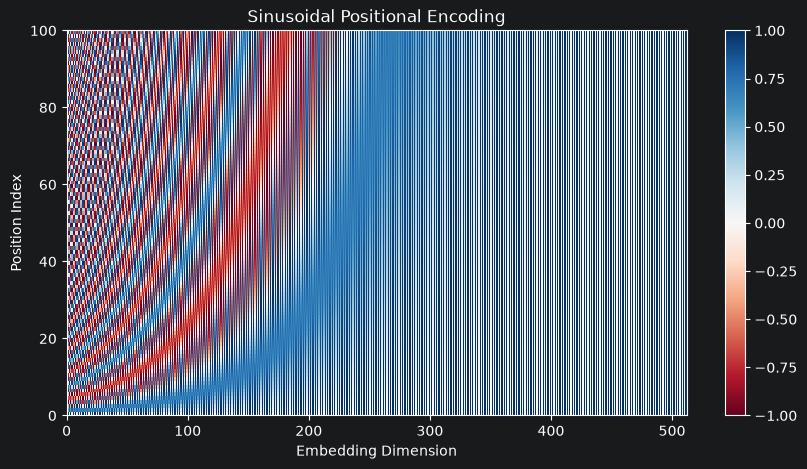

In [11]:
import math  # 数学函数，用于 sqrt 放缩与位置编码频率计算

import torch  # PyTorch 核心库
import torch.nn as nn  # 神经网络模块
import matplotlib.pyplot as plt  # 绘图库，用于可视化位置编码


class TokenEmbedding(nn.Module):
    """
    词嵌入层: token id → d_model 维向量，并乘 sqrt(d_model) 放缩

    放缩的原因: 正弦位置编码的数值较小(±1以内)，
    若词嵌入不做放大，两者相加后位置信息会被词嵌入"淹没"。
    """

    def __init__(self, vocab_size, d_model, padding_idx=0):
        """
        参数:
            vocab_size: 词表大小
            d_model: 词嵌入维度(与模型隐层维度一致)
            padding_idx: PAD 的 id，该行嵌入固定为 0 且不参与梯度更新
        """
        super().__init__()  # 调用父类 nn.Module 构造函数
        self.d_model = d_model  # 保存维度，forward 放缩时使用
        self.emb = nn.Embedding(vocab_size, d_model, padding_idx=padding_idx)  # 查表嵌入层

    def forward(self, ids):
        # ids: (batch_size, seq_len)
        return self.emb(ids) * math.sqrt(self.d_model)  # 查表并乘 sqrt(d_model) 放缩


class PositionalEmbedding(nn.Module):
    """
    正弦位置编码: 为每个位置生成固定的(不可学习)位置向量

    偶数维用 sin、奇数维用 cos，不同维度对应不同波长的正弦波，
    使得任意位置 (pos+k) 的编码都能表示成 pos 位置编码的线性组合，
    从而让模型容易学到"相对位置"信息。
    """

    def __init__(self, d_model, max_len=512, dropout=0.1):
        """
        参数:
            d_model: 位置编码维度(与词嵌入维度一致)
            max_len: 预生成的最大序列长度
            dropout: dropout 概率
        """
        super().__init__()  # 调用父类构造函数
        self.dropout = nn.Dropout(p=dropout)  # 嵌入上的 dropout

        pe = torch.zeros(max_len, d_model)  # (max_len, d_model) 位置编码矩阵
        position = torch.arange(0, max_len).unsqueeze(1).float()  # (max_len, 1) 位置下标
        # div_term: 频率因子 10000^(-2i/d_model)，维度越高频率越低(波长越长)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)  # 偶数维填 sin
        pe[:, 1::2] = torch.cos(position * div_term)  # 奇数维填 cos

        pe = pe.unsqueeze(0)  # (1, max_len, d_model)，增加 batch 维便于广播
        # register_buffer: 注册为不参与训练的常量，但会随模型保存/移动设备
        self.register_buffer("pe", pe)

    def forward(self, x):
        # x: (batch_size, seq_len, d_model) 词嵌入结果
        x = x + self.pe[:, : x.size(1)]  # 截取前 seq_len 个位置并与词嵌入相加
        return self.dropout(x)  # dropout 正则化


class TransformerEmbedding(nn.Module):
    """
    Transformer 总嵌入 = TokenEmbedding(查表+放缩) + PositionalEmbedding(位置信息)
    """

    def __init__(self, vocab_size, d_model, max_len=512, dropout=0.1):
        """
        参数:
            vocab_size: 词表大小
            d_model: 词嵌入维度
            max_len: 位置编码最大长度
            dropout: dropout 概率
        """
        super().__init__()  # 调用父类构造函数
        self.token_emb = TokenEmbedding(vocab_size, d_model)  # 词嵌入
        self.pos_emb = PositionalEmbedding(d_model, max_len, dropout)  # 位置编码

    def forward(self, ids):
        # ids: (batch_size, seq_len)
        embed = self.token_emb(ids)  # (batch_size, seq_len, d_model)
        embed = self.pos_emb(embed)  # 加上位置编码并 dropout
        return embed


# 用法示例: 用共享词表构建嵌入层，并对一个 batch 的源句做嵌入
embedding = TransformerEmbedding(vocab_size=tokenizer.vocab_size, d_model=512)  # 创建嵌入层
embed = embedding(encoder_inputs)  # (batch_size, src_len, 512)

print("encoder_inputs shape:", encoder_inputs.shape)  # 打印输入形状
print("embedding shape:", embed.shape)  # 打印嵌入形状

# 可视化前 100 个位置的位置编码(不同维度是不同波长的正弦/余弦波)
plt.figure(figsize=(10, 5))  # 创建画布
plt.pcolormesh(embedding.pos_emb.pe[0][:100].numpy(), cmap="RdBu")  # 位置编码矩阵热力图
plt.xlabel("Embedding Dimension")  # 横轴: 维度
plt.ylabel("Position Index")  # 纵轴: 位置
plt.title("Sinusoidal Positional Encoding")  # 标题
plt.colorbar()  # 颜色条
plt.show()  # 显示图像


## 6. 多头注意力 —— MultiHeadAttention 与掩码

缩放点积注意力 softmax(QKᵀ/√d_k)V 切成 n_heads 个子空间并行计算后拼接；padding 掩码屏蔽 PAD 位置，因果掩码防止解码时"偷看未来"。


In [12]:
import math  # 数学函数，用于 sqrt(d_k) 缩放

import torch  # PyTorch 核心库
import torch.nn as nn  # 神经网络模块
import torch.nn.functional as F  # 函数式接口，提供 softmax


def generate_padding_mask(mask):
    """
    将 (batch_size, seq_len) 的 padding mask(1=PAD)
    扩展为可作用于注意力分数的布尔掩码 (batch_size, 1, 1, seq_len)，
    True 表示该位置是 PAD，需要屏蔽。
    """
    # mask==1 即 PAD 位置，转 bool 后增加两个维度:
    # (batch, seq_len) → (batch, 1, 1, seq_len)，可广播到 (batch, n_heads, q_len, k_len)
    return (mask == 1).unsqueeze(1).unsqueeze(2)


def generate_causal_mask(seq_len):
    """
    生成因果掩码 (seq_len, seq_len)，上三角为 True(屏蔽)。
    保证位置 i 只能关注 0..i 位置，防止解码时"偷看未来"。
    """
    # triu 取上三角(diagonal=1 不含对角线)，"未来"位置为 True
    return torch.triu(torch.ones(seq_len, seq_len), diagonal=1).bool()


class MultiHeadAttention(nn.Module):
    """
    多头注意力: 将 d_model 切成 n_heads 份并行做缩放点积注意力

    Attention(Q, K, V) = softmax(Q·Kᵀ / sqrt(d_k)) · V
    多头的作用: 让不同子空间关注不同的模式(句法/语义/位置关系等)，
    最后拼接并做一次线性变换融合各头信息。
    """

    def __init__(self, d_model, n_heads, dropout=0.1):
        """
        参数:
            d_model: 输入特征维度
            n_heads: 注意力头数，需满足 d_model % n_heads == 0
            dropout: 注意力权重上的 dropout 概率
        """
        super().__init__()  # 调用父类构造函数
        assert d_model % n_heads == 0  # d_model 必须能被头数整除
        self.d_model = d_model  # 总维度
        self.d_k = d_model // n_heads  # 每个头的维度
        self.n_heads = n_heads  # 头数

        self.Wq = nn.Linear(d_model, d_model)  # 查询(Query)投影
        self.Wk = nn.Linear(d_model, d_model)  # 键(Key)投影
        self.Wv = nn.Linear(d_model, d_model)  # 值(Value)投影
        self.out_proj = nn.Linear(d_model, d_model)  # 输出投影
        self.dropout = nn.Dropout(p=dropout)  # 注意力权重 dropout

    def forward(self, query, key, value, attn_mask=None):
        """
        参数:
            query: (batch_size, q_len, d_model)
            key / value: (batch_size, k_len, d_model)
            attn_mask: 布尔掩码，可广播到 (batch_size, n_heads, q_len, k_len)，
                       True 表示屏蔽(注意力分数填 -1e9，softmax 后权重≈0)
        返回:
            output: (batch_size, q_len, d_model)
            attn_weights: (batch_size, n_heads, q_len, k_len)
        """
        batch_size = query.size(0)  # batch 大小

        # 线性投影后拆多头: (batch, len, d_model) → (batch, n_heads, len, d_k)
        Q = self.Wq(query).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        K = self.Wk(key).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        V = self.Wv(value).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)

        # 注意力分数: (batch, n_heads, q_len, k_len)，除以 sqrt(d_k) 防止点积过大导致 softmax 饱和
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)

        if attn_mask is not None:  # 屏蔽 PAD 位置或未来位置
            scores = scores.masked_fill(attn_mask, -1e9)  # 屏蔽位置填 -1e9，softmax 后权重≈0

        attn_weights = F.softmax(scores, dim=-1)  # 最后一维(键)归一化
        attn_weights = self.dropout(attn_weights)  # 训练时随机丢弃部分注意力

        # 加权求和: (batch, n_heads, q_len, d_k)
        context = torch.matmul(attn_weights, V)

        # 合并多头: (batch, n_heads, q_len, d_k) → (batch, q_len, d_model)
        context = context.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        output = self.out_proj(context)  # 输出线性变换
        return output, attn_weights


# 用法示例 1: encoder 自注意力(屏蔽源句 PAD 位置)
attention = MultiHeadAttention(d_model=512, n_heads=8)  # 创建多头注意力模块

padding_mask = generate_padding_mask(encoder_inputs_mask)  # (batch, 1, 1, src_len)，True=PAD
print("padding mask shape:", padding_mask.shape)  # 打印掩码形状

enc_attn_out, enc_attn_weights = attention(embed, embed, embed, attn_mask=padding_mask)  # Q=K=V 即自注意力
print("encoder 自注意力输出 shape:", enc_attn_out.shape)  # (batch, src_len, d_model)
print("encoder 自注意力权重 shape:", enc_attn_weights.shape)  # (batch, n_heads, src_len, src_len)

# 用法示例 2: 因果掩码演示(6×6 上三角，1=被屏蔽的"未来"位置)
causal_mask = generate_causal_mask(6)  # 生成 6×6 因果掩码
print("因果掩码(6×6，1=屏蔽):")  # 打印标题
print(causal_mask.int())  # 打印掩码内容


padding mask shape: torch.Size([26, 1, 1, 20])
encoder 自注意力输出 shape: torch.Size([26, 20, 512])
encoder 自注意力权重 shape: torch.Size([26, 8, 20, 20])
因果掩码(6×6，1=屏蔽):
tensor([[0, 1, 1, 1, 1, 1],
        [0, 0, 1, 1, 1, 1],
        [0, 0, 0, 1, 1, 1],
        [0, 0, 0, 0, 1, 1],
        [0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 0]], dtype=torch.int32)


## 7. 前馈网络与编解码层 —— FeedForward / EncoderLayer / DecoderLayer

PositionwiseFeedForward 对每个位置独立做升维-激活-降维；EncoderLayer = 自注意力 + FFN；DecoderLayer = 因果自注意力 + 交叉注意力 + FFN；各子层均带残差连接与 LayerNorm。


In [13]:
import torch  # PyTorch 核心库
import torch.nn as nn  # 神经网络模块
import torch.nn.functional as F  # 函数式接口，提供 relu


class PositionwiseFeedForward(nn.Module):
    """
    逐位置前馈网络: 两层 MLP，先升维(d_model→d_ff)过 ReLU 再降回 d_model

    注意力负责"混合"不同位置的信息，FFN 则对每个位置独立做非线性变换，
    相当于对每个 token 单独做一次特征加工。
    """

    def __init__(self, d_model, d_ff, dropout=0.1):
        """
        参数:
            d_model: 输入/输出维度
            d_ff: 中间升维维度(通常为 d_model 的 4 倍)
            dropout: dropout 概率
        """
        super().__init__()  # 调用父类构造函数
        self.w_1 = nn.Linear(d_model, d_ff)  # 升维层
        self.w_2 = nn.Linear(d_ff, d_model)  # 降维层
        self.dropout = nn.Dropout(p=dropout)  # 中间层 dropout

    def forward(self, x):
        # x: (batch, seq_len, d_model)
        return self.w_2(self.dropout(F.relu(self.w_1(x))))  # 升维→ReLU→dropout→降维


class EncoderLayer(nn.Module):
    """
    编码器层: 自注意力 + Add&Norm + FFN + Add&Norm

    残差连接缓解深层网络的梯度消失，LayerNorm 稳定每层输出的分布。
    """

    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        """
        参数:
            d_model: 隐层维度
            n_heads: 注意力头数
            d_ff: 前馈网络升维维度
            dropout: dropout 概率
        """
        super().__init__()  # 调用父类构造函数
        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout)  # 子层1: 自注意力
        self.norm1 = nn.LayerNorm(d_model)  # 子层1 的 LayerNorm
        self.ffn = PositionwiseFeedForward(d_model, d_ff, dropout)  # 子层2: 前馈网络
        self.norm2 = nn.LayerNorm(d_model)  # 子层2 的 LayerNorm
        self.dropout1 = nn.Dropout(dropout)  # 子层1 的 dropout
        self.dropout2 = nn.Dropout(dropout)  # 子层2 的 dropout

    def forward(self, x, self_attn_mask=None):
        """
        参数:
            x: (batch, seq_len, d_model)
            self_attn_mask: 编码器自注意力掩码(padding mask)
        """
        # 子层1: 多头自注意力(残差 + LayerNorm)
        attn_out, _ = self.self_attn(x, x, x, attn_mask=self_attn_mask)  # Q=K=V
        x = self.norm1(x + self.dropout1(attn_out))  # Add & Norm
        # 子层2: 前馈网络(残差 + LayerNorm)
        ffn_out = self.ffn(x)  # 逐位置变换
        x = self.norm2(x + self.dropout2(ffn_out))  # Add & Norm
        return x


class DecoderLayer(nn.Module):
    """
    解码器层: 因果自注意力 + 编码器-解码器交叉注意力 + FFN，各子层均带 Add&Norm

    交叉注意力: Query 来自 decoder，Key/Value 来自 encoder 输出，
    这是解码器"看源句"的通道，等价于 Seq2Seq 中的 Attention。
    """

    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        """
        参数:
            d_model: 隐层维度
            n_heads: 注意力头数
            d_ff: 前馈网络升维维度
            dropout: dropout 概率
        """
        super().__init__()  # 调用父类构造函数
        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout)  # 子层1: 因果自注意力
        self.cross_attn = MultiHeadAttention(d_model, n_heads, dropout)  # 子层2: 交叉注意力
        self.ffn = PositionwiseFeedForward(d_model, d_ff, dropout)  # 子层3: 前馈网络
        self.norm1 = nn.LayerNorm(d_model)  # 子层1 的 LayerNorm
        self.norm2 = nn.LayerNorm(d_model)  # 子层2 的 LayerNorm
        self.norm3 = nn.LayerNorm(d_model)  # 子层3 的 LayerNorm
        self.dropout1 = nn.Dropout(dropout)  # 子层1 的 dropout
        self.dropout2 = nn.Dropout(dropout)  # 子层2 的 dropout
        self.dropout3 = nn.Dropout(dropout)  # 子层3 的 dropout

    def forward(self, x, encoder_out, self_attn_mask=None, cross_attn_mask=None):
        """
        参数:
            x: (batch, tgt_len, d_model) decoder 当前表示
            encoder_out: (batch, src_len, d_model) encoder 输出
            self_attn_mask: 因果+padding 组合掩码
            cross_attn_mask: 源句 padding 掩码
        """
        # 子层1: decoder 因果自注意力
        attn_out, _ = self.self_attn(x, x, x, attn_mask=self_attn_mask)  # Q=K=V
        x = self.norm1(x + self.dropout1(attn_out))  # Add & Norm
        # 子层2: 交叉注意力(Q 来自 decoder，K/V 来自 encoder 输出)
        attn_out, _ = self.cross_attn(x, encoder_out, encoder_out, attn_mask=cross_attn_mask)
        x = self.norm2(x + self.dropout2(attn_out))  # Add & Norm
        # 子层3: 前馈网络
        ffn_out = self.ffn(x)  # 逐位置变换
        x = self.norm3(x + self.dropout3(ffn_out))  # Add & Norm
        return x


# 用法示例: 分别对前馈网络与编码器/解码器的一层做前向
ffn = PositionwiseFeedForward(d_model=512, d_ff=2048)  # 创建前馈网络
ffn_out = ffn(embed)  # (batch, src_len, 512)
print("FFN 输出 shape:", ffn_out.shape)  # 打印形状

enc_layer = EncoderLayer(d_model=512, n_heads=8, d_ff=2048)  # 创建编码器层
enc_layer_out = enc_layer(embed, generate_padding_mask(encoder_inputs_mask))  # 前向(带 padding 掩码)
print("EncoderLayer 输出 shape:", enc_layer_out.shape)  # 打印形状

dec_layer = DecoderLayer(d_model=512, n_heads=8, d_ff=2048)  # 创建解码器层
dec_layer_out = dec_layer(embed, enc_layer_out)  # 前向(演示用，暂不传掩码)
print("DecoderLayer 输出 shape:", dec_layer_out.shape)  # 打印形状


FFN 输出 shape: torch.Size([26, 20, 512])
EncoderLayer 输出 shape: torch.Size([26, 20, 512])
DecoderLayer 输出 shape: torch.Size([26, 20, 512])


## 8. 搭建 Transformer 总模型

Encoder 堆叠编码源句，Decoder 结合因果自注意力与交叉注意力自回归解码，Classifier 投影到词表；forward 为 Teacher Forcing 训练，infer 为贪心自回归推理。


In [14]:
import torch  # PyTorch 核心库
import torch.nn as nn  # 神经网络模块


class Encoder(nn.Module):
    """
    编码器: TransformerEmbedding(词+位置) + N 层 EncoderLayer 堆叠

    输出源句每个位置的上下文表示，供 Decoder 的交叉注意力使用。
    """

    def __init__(self, vocab_size, d_model, n_heads, d_ff, num_layers, max_len=512, dropout=0.1):
        """
        参数:
            vocab_size: 源语言词表大小
            d_model: 隐层维度
            n_heads: 注意力头数
            d_ff: 前馈网络升维维度
            num_layers: 编码器层数
            max_len: 位置编码最大长度
            dropout: dropout 概率
        """
        super().__init__()  # 调用父类构造函数
        self.embedding = TransformerEmbedding(vocab_size, d_model, max_len, dropout)  # 嵌入层
        self.layers = nn.ModuleList(  # N 层编码器层
            [EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(num_layers)]
        )

    def forward(self, encoder_inputs, encoder_inputs_mask=None):
        """
        参数:
            encoder_inputs: (batch, src_len) 源句 id
            encoder_inputs_mask: (batch, src_len) 1=PAD
        返回:
            encoder_out: (batch, src_len, d_model)
        """
        x = self.embedding(encoder_inputs)  # (batch, src_len, d_model)
        # padding 掩码: (batch, 1, 1, src_len)，屏蔽源句 PAD 位置
        self_attn_mask = (
            generate_padding_mask(encoder_inputs_mask) if encoder_inputs_mask is not None else None
        )
        for layer in self.layers:  # 逐层堆叠
            x = layer(x, self_attn_mask)  # 每层内部做自注意力+FFN
        return x


class Decoder(nn.Module):
    """
    解码器: TransformerEmbedding + N 层 DecoderLayer 堆叠

    自注意力带因果掩码(不看未来)，交叉注意力看编码器输出(不看源句 PAD)。
    """

    def __init__(self, vocab_size, d_model, n_heads, d_ff, num_layers, max_len=512, dropout=0.1):
        """
        参数:
            vocab_size: 目标语言词表大小
            d_model: 隐层维度
            n_heads: 注意力头数
            d_ff: 前馈网络升维维度
            num_layers: 解码器层数
            max_len: 位置编码最大长度
            dropout: dropout 概率
        """
        super().__init__()  # 调用父类构造函数
        self.embedding = TransformerEmbedding(vocab_size, d_model, max_len, dropout)  # 嵌入层
        self.layers = nn.ModuleList(  # N 层解码器层
            [DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(num_layers)]
        )

    def forward(self, decoder_inputs, encoder_out, decoder_inputs_mask=None, encoder_inputs_mask=None):
        """
        参数:
            decoder_inputs: (batch, tgt_len) 目标句输入
            encoder_out: (batch, src_len, d_model) 编码器输出
            decoder_inputs_mask: (batch, tgt_len) 1=PAD
            encoder_inputs_mask: (batch, src_len) 1=PAD
        返回:
            decoder_out: (batch, tgt_len, d_model)
        """
        tgt_len = decoder_inputs.size(1)  # 目标句长度
        x = self.embedding(decoder_inputs)  # (batch, tgt_len, d_model)

        # 因果掩码: (tgt_len, tgt_len) → (1, 1, tgt_len, tgt_len)，与输入设备对齐
        causal_mask = generate_causal_mask(tgt_len).to(decoder_inputs.device).unsqueeze(0).unsqueeze(0)
        # decoder padding 掩码: (batch, 1, 1, tgt_len)
        padding_mask = (
            generate_padding_mask(decoder_inputs_mask) if decoder_inputs_mask is not None else None
        )
        # 组合掩码: 因果 OR padding，广播为 (batch, 1, tgt_len, tgt_len)
        self_attn_mask = causal_mask if padding_mask is None else causal_mask | padding_mask
        # 交叉注意力掩码: 屏蔽源句 PAD 位置
        cross_attn_mask = (
            generate_padding_mask(encoder_inputs_mask) if encoder_inputs_mask is not None else None
        )

        for layer in self.layers:  # 逐层堆叠
            x = layer(x, encoder_out, self_attn_mask, cross_attn_mask)  # 因果自注意力+交叉注意力+FFN
        return x


class Transformer(nn.Module):
    """
    Transformer 机器翻译模型（《Attention Is All You Need》）

    组成: Encoder(源句编码) + Decoder(自回归解码) + Classifier(词表投影)
    forward: Teacher Forcing 训练，一次前向得到所有位置的 logits
    infer:   贪心自回归推理，从 BOS 开始逐步解码直到 EOS
    """

    def __init__(
        self,
        src_vocab_size,  # 源语言词表大小
        tgt_vocab_size,  # 目标语言词表大小
        d_model=512,  # 隐层维度
        n_heads=8,  # 注意力头数
        num_encoder_layers=6,  # 编码器层数
        num_decoder_layers=6,  # 解码器层数
        d_ff=2048,  # 前馈网络升维维度
        max_len=512,  # 位置编码最大长度
        dropout=0.1,  # dropout 概率
        pad_idx=0,  # PAD id
        bos_idx=1,  # BOS id，推理时解码起始符号
        eos_idx=3,  # EOS id，推理时遇到则停止解码
    ):
        """参数含义见上方行内注释。"""
        super().__init__()  # 调用父类构造函数
        self.pad_idx = pad_idx  # 保存 PAD id
        self.bos_idx = bos_idx  # 保存 BOS id
        self.eos_idx = eos_idx  # 保存 EOS id

        self.encoder = Encoder(  # 编码器
            src_vocab_size, d_model, n_heads, d_ff, num_encoder_layers, max_len, dropout
        )
        self.decoder = Decoder(  # 解码器
            tgt_vocab_size, d_model, n_heads, d_ff, num_decoder_layers, max_len, dropout
        )
        self.classifier = nn.Linear(d_model, tgt_vocab_size)  # 输出层: d_model → 词表大小

    def forward(self, encoder_inputs, decoder_inputs, encoder_inputs_mask=None):
        """
        Teacher Forcing 前向: 输入完整源句与"右移一位"的目标句，一次输出所有位置 logits。

        参数:
            encoder_inputs: (batch, src_len) 源句 id(含 BOS/EOS)
            decoder_inputs: (batch, tgt_len) 目标句输入(含 BOS、不含 EOS)
            encoder_inputs_mask: (batch, src_len) 1=PAD
        返回:
            logits: (batch, tgt_len, tgt_vocab_size)
        """
        # decoder 自注意力需要屏蔽 decoder 输入自身的 PAD 位置(1=PAD，与 encoder 掩码约定一致)
        decoder_inputs_mask = (decoder_inputs == self.pad_idx).to(torch.int64)
        encoder_out = self.encoder(encoder_inputs, encoder_inputs_mask)  # 编码源句
        decoder_out = self.decoder(  # 解码(因果自注意力 + 交叉注意力)
            decoder_inputs, encoder_out, decoder_inputs_mask, encoder_inputs_mask
        )
        logits = self.classifier(decoder_out)  # (batch, tgt_len, tgt_vocab_size)
        return logits

    @torch.no_grad()  # 关闭梯度（装饰器）
    def infer(self, encoder_inputs, encoder_inputs_mask=None, max_length=60):
        """
        贪心自回归推理: 从 BOS 开始逐步解码，全部样本生成 EOS 或达到 max_length 停止。

        参数:
            encoder_inputs: (batch, src_len) 源句 id
            encoder_inputs_mask: (batch, src_len) 1=PAD
            max_length: 最大解码步数
        返回:
            predictions: (batch, 实际解码长度)，生成的 token id(不含起始 BOS)
        """
        batch_size = encoder_inputs.size(0)  # batch 大小
        device = encoder_inputs.device  # 输入所在设备

        encoder_out = self.encoder(encoder_inputs, encoder_inputs_mask)  # 编码源句(只算一次)

        # 初始 decoder 输入: 全 batch 填 BOS，形状 (batch, 1)
        decoder_inputs = torch.full(
            (batch_size, 1), self.bos_idx, dtype=torch.long, device=device
        )
        finished = torch.zeros(batch_size, dtype=torch.bool, device=device)  # 标记各样本是否已生成 EOS

        for _ in range(max_length):  # 最多解码 max_length 步
            decoder_inputs_mask = (decoder_inputs == self.pad_idx).to(torch.int64)  # 1=PAD
            decoder_out = self.decoder(  # 对当前前缀做一次完整前向
                decoder_inputs, encoder_out, decoder_inputs_mask, encoder_inputs_mask
            )
            logits = self.classifier(decoder_out[:, -1, :])  # 只取最后一个时间步 (batch, tgt_vocab_size)
            next_token = logits.argmax(dim=-1)  # 贪心: 取概率最大的 token

            # 已结束的样本不再生成新 token，用 PAD 填充
            next_token = torch.where(
                finished,  # 是否已结束
                torch.full_like(next_token, self.pad_idx),  # 结束则填 PAD
                next_token,  # 未结束则用预测 token
            )

            decoder_inputs = torch.cat(  # 拼接当前预测，作为下一步的前缀
                [decoder_inputs, next_token.unsqueeze(1)], dim=1
            )
            finished = finished | (next_token == self.eos_idx)  # 生成 EOS 的样本标记为已完成
            if finished.all():  # 全部样本完成则提前退出
                break

        return decoder_inputs[:, 1:]  # 去掉起始 BOS 返回


# 用法示例: 用训练配置实例化模型(base 配置的缩小版)并做形状测试与贪心推理
model = Transformer(  # 创建 Transformer 模型
    src_vocab_size=tokenizer.vocab_size,  # 源语言词表大小(共享词表)
    tgt_vocab_size=tokenizer.vocab_size,  # 目标语言词表大小(共享词表)
    d_model=256,  # 隐层维度
    n_heads=8,  # 注意力头数
    num_encoder_layers=3,  # 编码器层数
    num_decoder_layers=3,  # 解码器层数
    d_ff=1024,  # 前馈网络升维维度
    max_len=512,  # 位置编码最大长度
    dropout=0.1,  # dropout 概率
    pad_idx=tokenizer.pad_idx,  # PAD id
    bos_idx=tokenizer.bos_idx,  # BOS id
    eos_idx=tokenizer.eos_idx,  # EOS id
)

logits = model(encoder_inputs, decoder_inputs, encoder_inputs_mask)  # Teacher Forcing 前向
print("encoder_inputs shape:", encoder_inputs.shape)  # 打印输入形状
print("decoder_inputs shape:", decoder_inputs.shape)  # 打印输入形状
print("logits shape:", logits.shape)  # (batch, tgt_len, vocab_size)

# 贪心推理(未训练模型输出为"乱码"属正常，仅验证推理流程)
model.eval()  # 评估模式
pred_ids = model.infer(encoder_inputs[:2], encoder_inputs_mask=encoder_inputs_mask[:2], max_length=20)  # 取前 2 条推理
print("infer pred_ids shape:", pred_ids.shape)  # 打印预测形状
print("推理结果:", tokenizer.decode(pred_ids.tolist()))  # 打印解码文本(未训练，为乱码)
print("参考译文:", tokenizer.decode(decoder_labels[:2].tolist()))  # 打印参考译文对照


encoder_inputs shape: torch.Size([26, 20])
decoder_inputs shape: torch.Size([26, 17])
logits shape: torch.Size([26, 17, 20001])
infer pred_ids shape: torch.Size([2, 20])
推理结果: ['▁upright gehende ▁contain ▁beteiligt ▁gl ▁theater ▁einkaufspassage ▁die ▁ras ▁chee eink ▁blase ▁choppy ▁angriff ▁mall ▁notebook ▁manche iving lasten ▁vorlesung', '▁upright ▁kapuz ▁mechan ▁untergrund ▁jumpsuit stas ▁spike ▁95 ▁sauce lass ▁su ▁befahrenen ▁monopoly ▁seichtem ▁anweis ▁stolz ▁knabbert ▁swan ichts ▁dist']
参考译文: ['▁colorfully ▁dressed ▁man ▁dancing ▁in ▁the ▁streets ▁, ▁while ▁balancing ▁something ▁on ▁his ▁head ▁.', '▁a ▁person ▁sits ▁in ▁rocks ▁in ▁waterproof ▁gear ▁with ▁their ▁boots ▁in ▁the ▁water ▁.']


## 9. 编写损失函数

`CrossEntropyLoss(ignore_index=PAD, label_smoothing=0.1)`：忽略 PAD 位置的标签，标签平滑防止模型过度自信。


In [15]:
import torch  # PyTorch 核心库
import torch.nn as nn  # 神经网络模块，提供 CrossEntropyLoss


# label_smoothing: 把真实标签的 one-hot 目标从 1 平滑为 1-smoothing，
# 其余类别均分 smoothing 概率。防止模型对预测过度自信，提升泛化(对翻译质量/BLEU 有帮助)。
# ignore_index=0: decoder_labels 中 PAD 的 id 为 0，PAD 位置不计损失
# (交叉熵内部已忽略 PAD，无需再手动乘 decoder_labels_mask)。
criterion = nn.CrossEntropyLoss(ignore_index=0, label_smoothing=0.1)  # 带标签平滑的交叉熵


def sequence_loss(logits, decoder_labels):
    """
    计算(带标签平滑的)序列交叉熵损失。

    参数:
        logits: (batch_size, tgt_len, vocab_size) 模型预测
        decoder_labels: (batch_size, tgt_len) 目标句标签(不含 BOS、含 EOS、含 PAD)
    返回:
        loss: 标量损失
    """
    logits_flat = logits.reshape(-1, logits.size(-1))  # 展平为 (batch*tgt_len, vocab_size)
    labels_flat = decoder_labels.reshape(-1)  # 展平为 (batch*tgt_len,)
    return criterion(logits_flat, labels_flat)  # 计算交叉熵(PAD 已忽略)


# 用法示例: 用前面的 batch 计算一次损失并验证梯度可回传
loss = sequence_loss(logits, decoder_labels)  # 计算损失
print("loss:", loss.item())  # 打印损失值(未训练模型约等于 log(词表大小)≈9.9)
loss.backward()  # 反向传播
print("backward ok")  # 打印提示


loss: 10.031534194946289
backward ok


## 10. Noam 优化器与学习率调度

lr = factor · d_model^(-0.5) · min(step^(-0.5), step·warmup^(-1.5))：前 warmup 步线性预热，之后按步数平方根倒数衰减。


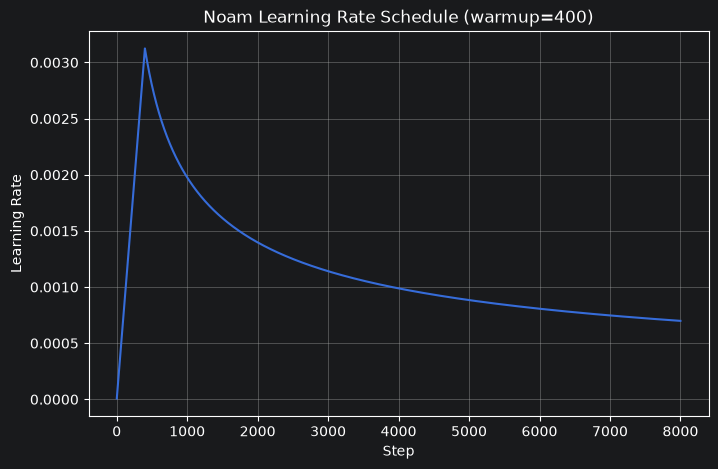

峰值学习率(第 400 步): 0.003125


In [16]:
import torch  # PyTorch 核心库
import matplotlib.pyplot as plt  # 绘图库，用于可视化学习率曲线


class NoamOpt:
    """
    Noam 学习率调度（《Attention Is All You Need》）

    lr(step) = factor * d_model^(-0.5) * min(step^(-0.5), step * warmup^(-1.5))
    - 预热阶段(step < warmup): 学习率随 step 线性增长
    - 衰减阶段(step > warmup): 学习率按 step 的平方根倒数衰减
    预热可避免训练初期大梯度导致发散，衰减让后期精细收敛。
    """

    def __init__(self, model_size, factor, warmup, optimizer):
        """
        参数:
            model_size: 模型隐层维度 d_model
            factor: 学习率缩放系数
            warmup: 预热步数
            optimizer: 底层优化器(如 Adam)
        """
        self.optimizer = optimizer  # 底层优化器
        self._step = 0  # 当前训练步数
        self.model_size = model_size  # 模型维度
        self.factor = factor  # 缩放系数
        self.warmup = warmup  # 预热步数

    def rate(self, step=None):
        """计算第 step 步的学习率。"""
        if step is None:  # 未指定时用当前步数
            step = self._step
        return self.factor * (
            self.model_size ** (-0.5) * min(step ** (-0.5), step * self.warmup ** (-1.5))
        )

    def zero_grad(self):
        """清空梯度(委托给底层优化器)。"""
        self.optimizer.zero_grad()  # 清空梯度

    def step(self):
        """更新学习率并执行一步参数更新。"""
        self._step += 1  # 步数 +1
        lr = self.rate()  # 计算当前学习率
        for p in self.optimizer.param_groups:  # 更新所有参数组的学习率
            p["lr"] = lr
        self.optimizer.step()  # 执行参数更新


# 用法示例: 可视化学习率曲线(预热 400 步内线性增长，之后平方根倒数衰减)
optimizer = NoamOpt(  # 创建 Noam 优化器
    model_size=256,  # 与 d_model 一致
    factor=1.0,  # 缩放系数
    warmup=400,  # 预热步数
    optimizer=torch.optim.Adam(  # 底层 Adam 优化器
        model.parameters(), lr=0, betas=(0.9, 0.98), eps=1e-9  # Transformer 论文推荐超参
    ),
)

steps = range(1, 8001)  # 前 8000 步
lrs = [optimizer.rate(step) for step in steps]  # 各步学习率

plt.figure(figsize=(8, 5))  # 创建画布
plt.plot(list(steps), lrs)  # 绘制学习率曲线
plt.xlabel("Step")  # 横轴: 训练步数
plt.ylabel("Learning Rate")  # 纵轴: 学习率
plt.title("Noam Learning Rate Schedule (warmup=400)")  # 标题
plt.grid(True)  # 网格
plt.show()  # 显示图像

print(f"峰值学习率(第 {optimizer.warmup} 步): {optimizer.rate(optimizer.warmup):.6f}")  # 打印峰值学习率


## 11. 训练与评估

`train_one_epoch` / `evaluate` / `fit` 完成训练循环，按有效 token 加权平均 loss，输出困惑度并绘制损失曲线，最后保存模型权重。


当前设备: cuda

Epoch 1/20
  batch  100/883, train_loss=7.0522
  batch  200/883, train_loss=6.1040
  batch  300/883, train_loss=5.6666
  batch  400/883, train_loss=5.4273
  batch  500/883, train_loss=5.3056
  batch  600/883, train_loss=5.2126
  batch  700/883, train_loss=5.1372
  batch  800/883, train_loss=5.0555
  batch  883/883, train_loss=5.0147
  已评估 batch   10/36
  已评估 batch   20/36
  已评估 batch   30/36
  已评估 batch   36/36
Epoch 1 完成: train_loss=5.0147, val_loss=4.5077, train_ppl=150.61, val_ppl=90.71

Epoch 2/20
  batch  100/883, train_loss=4.6104
  batch  200/883, train_loss=4.5357
  batch  300/883, train_loss=4.4871
  batch  400/883, train_loss=4.4556
  batch  500/883, train_loss=4.4460
  batch  600/883, train_loss=4.4366
  batch  700/883, train_loss=4.4259
  batch  800/883, train_loss=4.3981
  batch  883/883, train_loss=4.3938
  已评估 batch   10/36
  已评估 batch   20/36
  已评估 batch   30/36
  已评估 batch   36/36
Epoch 2 完成: train_loss=4.3938, val_loss=4.2536, train_ppl=80.95, val_ppl=70.3

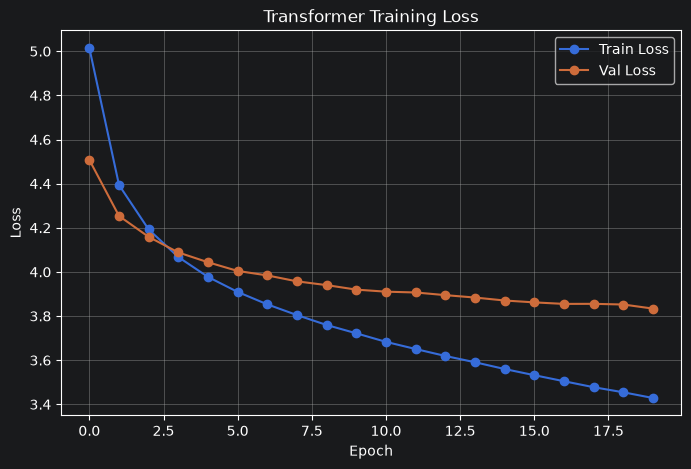

In [17]:
import math  # 数学函数，用于计算困惑度 exp
import torch  # PyTorch 核心库
import matplotlib.pyplot as plt  # 绘图库，用于绘制损失曲线


# =========================
# 1. 构建验证/测试集 DataLoader(不打乱顺序)
# =========================
val_batch_sampler = TransformerBatchSampler(val_ds, batch_size=512, shuffle_batch=False)  # 验证集采样器
val_dl = val_batch_sampler.build_dataloader(collate_fn_with_tokenizer)  # 验证集 DataLoader

test_batch_sampler = TransformerBatchSampler(test_ds, batch_size=512, shuffle_batch=False)  # 测试集采样器
test_dl = test_batch_sampler.build_dataloader(collate_fn_with_tokenizer)  # 测试集 DataLoader

# =========================
# 2. 初始化设备与模型
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # 自动选择设备
print("当前设备:", device)  # 打印设备

model = Transformer(  # 创建 Transformer 模型(与第 8 章相同配置)
    src_vocab_size=tokenizer.vocab_size,  # 源语言词表大小(共享词表)
    tgt_vocab_size=tokenizer.vocab_size,  # 目标语言词表大小(共享词表)
    d_model=256,  # 隐层维度
    n_heads=8,  # 注意力头数
    num_encoder_layers=3,  # 编码器层数
    num_decoder_layers=3,  # 解码器层数
    d_ff=1024,  # 前馈网络升维维度
    max_len=512,  # 位置编码最大长度
    dropout=0.1,  # dropout 概率
    pad_idx=tokenizer.pad_idx,  # PAD id
    bos_idx=tokenizer.bos_idx,  # BOS id
    eos_idx=tokenizer.eos_idx,  # EOS id
).to(device)  # 模型移到设备

# Noam 优化器: 前 warmup 步线性预热，之后按平方根倒数衰减
optimizer = NoamOpt(
    model_size=256,  # 与 d_model 一致
    factor=1.0,  # 学习率缩放系数(显存/时间充足可调大以加快收敛)
    warmup=400,  # 预热步数(约 1 个 epoch)
    optimizer=torch.optim.Adam(model.parameters(), lr=0, betas=(0.9, 0.98), eps=1e-9),  # 底层 Adam
)


# =========================
# 3. 训练与评估函数
# =========================
def move_batch_to_device(batch, device):
    """将 collate_fct 产出的 dict 类型 batch 的所有张量移动到指定设备。"""
    return {key: value.to(device) for key, value in batch.items()}  # 逐个张量移到设备


def train_one_epoch(model, dataloader, optimizer, device, log_every=100):
    """
    训练一个 epoch。
    返回按有效 token 数加权后的平均训练 loss。
    """
    model.train()  # 训练模式(开启 dropout)
    total_loss = 0.0  # 累计加权损失
    total_tokens = 0  # 累计有效 token 数

    for batch_idx, batch in enumerate(dataloader, start=1):  # 逐 batch 训练
        batch = move_batch_to_device(batch, device)  # 张量移到设备

        optimizer.zero_grad()  # 清空梯度
        logits = model(  # Teacher Forcing 前向传播
            batch["encoder_inputs"],  # 编码器输入
            batch["decoder_inputs"],  # 解码器输入
            batch["encoder_inputs_mask"],  # 编码器掩码
        )
        loss = sequence_loss(logits, batch["decoder_labels"])  # 计算损失(忽略 PAD + 标签平滑)
        loss.backward()  # 反向传播
        optimizer.step()  # 更新参数(NoamOpt 内部同时更新学习率)

        valid_tokens = (batch["decoder_labels"] != tokenizer.pad_idx).sum().item()  # 当前 batch 有效 token 数
        total_loss += loss.item() * valid_tokens  # 按有效 token 数加权累加
        total_tokens += valid_tokens  # 累加有效 token 数

        if batch_idx % log_every == 0 or batch_idx == len(dataloader):  # 定期打印进度
            avg_loss = total_loss / total_tokens  # 当前平均损失
            print(f"  batch {batch_idx:>4}/{len(dataloader)}, train_loss={avg_loss:.4f}")  # 打印平均损失

    return total_loss / total_tokens  # 返回按 token 加权的平均损失


@torch.no_grad()  # 关闭梯度（装饰器）
def evaluate(model, dataloader, device, log_every=10):
    """
    在验证/测试集上评估模型。
    返回按有效 token 数加权后的平均 loss。
    """
    model.eval()  # 评估模式(关闭 dropout)
    total_loss = 0.0  # 累计加权损失
    total_tokens = 0  # 累计有效 token 数

    for batch_idx, batch in enumerate(dataloader, start=1):  # 逐 batch 评估
        batch = move_batch_to_device(batch, device)  # 张量移到设备
        logits = model(  # Teacher Forcing 前向传播
            batch["encoder_inputs"],  # 编码器输入
            batch["decoder_inputs"],  # 解码器输入
            batch["encoder_inputs_mask"],  # 编码器掩码
        )
        loss = sequence_loss(logits, batch["decoder_labels"])  # 计算损失
        valid_tokens = (batch["decoder_labels"] != tokenizer.pad_idx).sum().item()  # 有效 token 数
        total_loss += loss.item() * valid_tokens  # 加权累加
        total_tokens += valid_tokens  # 累加

        if batch_idx % log_every == 0 or batch_idx == len(dataloader):  # 定期打印进度
            print(f"  已评估 batch {batch_idx:>4}/{len(dataloader)}")  # 打印进度

    return total_loss / total_tokens  # 返回平均损失


def fit(model, train_dl, val_dl, optimizer, device, epochs=20):
    """
    完整训练流程。
    每个 epoch 后在验证集上评估，记录损失并计算困惑度。
    """
    history = {  # 记录训练/验证损失
        "train_loss": [],  # 训练损失列表
        "val_loss": [],  # 验证损失列表
    }

    for epoch in range(1, epochs + 1):  # 逐 epoch 训练
        print(f"\nEpoch {epoch}/{epochs}")  # 打印当前轮次
        train_loss = train_one_epoch(model, train_dl, optimizer, device)  # 训练一轮
        val_loss = evaluate(model, val_dl, device)  # 验证一轮

        history["train_loss"].append(train_loss)  # 记录训练损失
        history["val_loss"].append(val_loss)  # 记录验证损失

        train_ppl = math.exp(train_loss) if train_loss < 20 else float("inf")  # 训练困惑度
        val_ppl = math.exp(val_loss) if val_loss < 20 else float("inf")  # 验证困惑度

        print(  # 打印本轮指标
            f"Epoch {epoch} 完成: "
            f"train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, "
            f"train_ppl={train_ppl:.2f}, val_ppl={val_ppl:.2f}"
        )

    return history  # 返回训练历史


# =========================
# 4. 开始训练并保存模型
# =========================
EPOCHS = 20  # 训练轮数(可按时间/显存调整)
history = fit(model, train_dl, val_dl, optimizer, device, epochs=EPOCHS)  # 开始训练

torch.save(model.state_dict(), "model/transformer_wmt16_de2en.pth")  # 保存模型权重
print("模型权重已保存: model/transformer_wmt16_de2en.pth")  # 打印保存路径

# =========================
# 5. 绘制损失曲线
# =========================
plt.figure(figsize=(8, 5))  # 创建画布
plt.plot(history["train_loss"], label="Train Loss", marker="o")  # 训练损失曲线
plt.plot(history["val_loss"], label="Val Loss", marker="o")  # 验证损失曲线
plt.xlabel("Epoch")  # 横轴: 轮数
plt.ylabel("Loss")  # 纵轴: 损失
plt.title("Transformer Training Loss")  # 标题
plt.legend()  # 图例
plt.grid(True)  # 网格
plt.show()  # 显示图像


## 12. 翻译推理样例

用训练好的模型对测试集德语句子做贪心解码，与参考译文对照查看翻译效果。


In [18]:
import torch  # PyTorch 核心库


@torch.no_grad()  # 关闭梯度（装饰器）
def translate(model, tokenizer, src_bpe_list, max_length=60, device="cpu"):
    """
    将德语 BPE 文本列表翻译为英语 BPE 文本列表(贪心自回归解码)。

    参数:
        model: 训练好的 Transformer 模型
        tokenizer: 共享词表 Tokenizer
        src_bpe_list: 德语 BPE 字符串列表(空格分隔子词)
        max_length: 最大解码步数
        device: 运行设备
    返回:
        英语 BPE 字符串列表
    """
    src_words = [text.split() for text in src_bpe_list]  # 切成 token 列表(encode 要求二维列表)
    encoder_inputs, encoder_inputs_mask = tokenizer.encode(  # 编码源句(加 BOS/EOS + padding)
        src_words, return_mask=True  # 同时返回 padding 掩码
    )
    pred_ids = model.infer(  # 贪心自回归推理
        encoder_inputs.to(device),  # 源句 id 移到设备
        encoder_inputs_mask=encoder_inputs_mask.to(device),  # 掩码移到设备
        max_length=max_length,  # 最大解码步数
    )
    return tokenizer.decode(pred_ids.cpu().tolist())  # 解码为英语 BPE 文本


# 取测试集前 3 条样本做翻译对照
model.eval()  # 评估模式
n = 3  # 展示样本数
samples = [test_ds[i] for i in range(n)]  # 取前 3 条 (德语 BPE, 英语 BPE)
src_bpe_list = [pair[0] for pair in samples]  # 德语源句
trg_bpe_list = [pair[1] for pair in samples]  # 英语参考译文
pred_bpe_list = translate(model, tokenizer, src_bpe_list, max_length=60, device=device)  # 模型翻译

for i in range(n):  # 逐条对照打印
    print(f"[{i + 1}] 源句(BPE): {src_bpe_list[i]}")  # 打印源句
    print(f"    预测(BPE): {pred_bpe_list[i]}")  # 打印预测
    print(f"    参考(BPE): {trg_bpe_list[i]}")  # 打印参考
    print("-" * 40)  # 分隔线


[1] 源句(BPE): ▁ein ▁mann ▁mit ▁einem ▁orangefarbenen ▁hut ▁, ▁der ▁etwas ▁anst arrt ▁.
    预测(BPE): ▁a ▁man ▁with ▁a ▁black ▁hat ▁is ▁looking ▁at ▁a ▁piece ▁of ▁paper ▁.
    参考(BPE): ▁a ▁man ▁in ▁an ▁orange ▁hat ▁starring ▁at ▁something ▁.
----------------------------------------
[2] 源句(BPE): ▁ein ▁boston ▁terrier ▁läuft ▁über ▁saft ig - grünes ▁gras ▁vor ▁einem ▁weißen ▁zaun ▁.
    预测(BPE): ▁a ▁white ▁and ▁white ▁dog ▁is ▁running ▁across ▁the ▁grass ▁in ▁front ▁of ▁a ▁white ▁grass ▁.
    参考(BPE): ▁a ▁boston ▁terrier ▁is ▁running ▁on ▁lush ▁green ▁grass ▁in ▁front ▁of ▁a ▁white ▁fence ▁.
----------------------------------------
[3] 源句(BPE): ▁ein ▁mädchen ▁in ▁einem ▁karateanzug ▁bricht ▁ein ▁brett ▁mit ▁einem ▁tritt ▁.
    预测(BPE): ▁a ▁girl ▁in ▁a ▁pink ▁dress ▁is ▁swimming ▁with ▁a ▁pool ▁.
    参考(BPE): ▁a ▁girl ▁in ▁karate ▁uniform ▁breaking ▁a ▁stick ▁with ▁a ▁front ▁kick ▁.
----------------------------------------


## 13. BLEU 指标评估

用 nltk 在测试集上计算语料级 BLEU 与句级 BLEU（子词级），量化翻译质量。


In [19]:
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu, SmoothingFunction  # nltk BLEU 计算


def ids_to_word_list(tokenizer, ids):
    """
    将 token id 列表转为 BPE 子词列表，去除 PAD/BOS/EOS/UNK 等特殊符号。
    用于 BLEU 计算时的 reference / hypothesis 输入。
    """
    words = []  # 收集子词
    special = {"[PAD]", "[BOS]", "[EOS]", "[UNK]"}  # 需去除的特殊符号(与 word2idx 定义一致)
    for idx in ids:  # 逐 id 查表
        token = tokenizer.idx2word.get(int(idx), "[UNK]")  # id → 子词
        if token in special:  # 特殊符号跳过
            continue
        words.append(token)  # 收集正常子词
    return words  # 返回子词列表


@torch.no_grad()  # 关闭梯度（装饰器）
def evaluate_bleu(model, dataloader, device, max_length=60):
    """
    在测试集上用贪心推理计算 BLEU 指标(子词级 BLEU)。

    返回:
        corpus_bleu_score: 语料级 BLEU
        avg_sentence_bleu: 句级 BLEU 的平均值
        references: 参考译文子词列表，每项为 [ref_tokens]
        hypotheses: 预测译文子词列表
    """
    model.eval()  # 评估模式
    smoothie = SmoothingFunction().method1  # 平滑方法(避免 n-gram 命中为 0 时得分恒为 0)
    weights = (0.25, 0.25, 0.25, 0.25)  # 4-gram BLEU

    references = []  # 参考译文列表
    hypotheses = []  # 预测译文列表
    sentence_bleu_scores = []  # 句级 BLEU 列表

    for batch_idx, batch in enumerate(dataloader, start=1):  # 逐 batch 评估
        batch = move_batch_to_device(batch, device)  # 张量移到设备
        pred_ids = model.infer(  # 贪心推理整批样本
            batch["encoder_inputs"],  # 编码器输入
            batch["encoder_inputs_mask"],  # 编码器掩码
            max_length=max_length,  # 最大解码步数
        )

        pred_ids_list = pred_ids.cpu().tolist()  # 预测 id 列表
        ref_ids_list = batch["decoder_labels"].cpu().tolist()  # 参考 id 列表

        for pred_ids_i, ref_ids_i in zip(pred_ids_list, ref_ids_list):  # 逐条样本
            hyp = ids_to_word_list(tokenizer, pred_ids_i)  # 预测子词列表
            ref = ids_to_word_list(tokenizer, ref_ids_i)  # 参考子词列表
            references.append([ref])  # corpus_bleu 要求每条样本是 [ref1, ref2, ...]
            hypotheses.append(hyp)  # 收集预测
            sentence_bleu_scores.append(  # 计算句级 BLEU
                sentence_bleu([ref], hyp, weights=weights, smoothing_function=smoothie)
            )

        if batch_idx % 10 == 0 or batch_idx == len(dataloader):  # 定期打印进度
            print(f"  已评估 batch {batch_idx:>4}/{len(dataloader)}")  # 打印进度

    corpus_bleu_score = corpus_bleu(  # 计算语料级 BLEU
        references, hypotheses, weights=weights, smoothing_function=smoothie
    )
    avg_sentence_bleu = sum(sentence_bleu_scores) / len(sentence_bleu_scores)  # 句级 BLEU 平均
    return corpus_bleu_score, avg_sentence_bleu, references, hypotheses


# =========================
# 测试集 BLEU 评估
# =========================
print("开始计算测试集 BLEU ...")  # 打印提示
corpus_bleu_score, avg_sentence_bleu, all_refs, all_hyps = evaluate_bleu(  # 开始评估
    model, test_dl, device, max_length=60  # 模型/测试集/设备/最大步数
)

print(f"\n测试集样本数: {len(all_hyps)}")  # 打印样本数
print(f"Corpus BLEU (4-gram): {corpus_bleu_score:.4f}")  # 打印语料级 BLEU
print(f"Average Sentence BLEU (4-gram): {avg_sentence_bleu:.4f}")  # 打印句级 BLEU

# 展示前 3 条样例，便于对照翻译效果
print("\nBLEU 评估样例（前 3 条）:")  # 打印标题
for i in range(min(3, len(all_hyps))):  # 展示前 3 条
    print(f"[{i + 1}] 预测: {' '.join(all_hyps[i])}")  # 打印预测
    print(f"    参考: {' '.join(all_refs[i][0])}")  # 打印参考
    print("-" * 40)  # 分隔线


开始计算测试集 BLEU ...
  已评估 batch   10/35
  已评估 batch   20/35
  已评估 batch   30/35
  已评估 batch   35/35

测试集样本数: 1000
Corpus BLEU (4-gram): 0.1718
Average Sentence BLEU (4-gram): 0.1498

BLEU 评估样例（前 3 条）:
[1] 预测: ▁two ▁men ▁with ▁hard ▁hats ▁are ▁swimming ▁.
    参考: ▁two ▁men ▁wearing ▁hats ▁.
----------------------------------------
[2] 预测: ▁young ▁woman ▁climbing ▁on ▁her ▁skateboard ▁.
    参考: ▁young ▁woman ▁climbing ▁rock ▁face
----------------------------------------
[3] 预测: ▁a ▁woman ▁playing ▁tennis ▁.
    参考: ▁a ▁woman ▁is ▁playing ▁volleyball ▁.
----------------------------------------


## 14. 总结

### 模型关键点

- 预处理：Moses 分词 + SentencePiece 联合 BPE，德英共享一套 2 万子词词表。
- 嵌入：词嵌入乘 sqrt(d_model) 放缩后与正弦位置编码相加。
- 注意力：缩放点积 + 多头；编码器自注意力用 padding 掩码，解码器自注意力用因果+padding 组合掩码，交叉注意力只看源句有效位置。
- 结构：EncoderLayer(自注意力+FFN) / DecoderLayer(因果自注意力+交叉注意力+FFN) 各 N 层堆叠，子层均带残差连接与 LayerNorm。
- 训练：Teacher Forcing + Label Smoothing 交叉熵（忽略 PAD），Noam 学习率调度（先预热后衰减），按 token 预算动态组批。
- 推理：从 BOS 开始贪心自回归解码，全部样本生成 EOS 后提前停止。

### 可改进方向

1. 用 beam search 代替贪心解码，缓解局部最优。
2. 网格搜索 label smoothing 系数、warmup 步数等超参数。
3. 增大模型规模（6 层 512 维 base 配置）与数据量、延长训练轮数。
4. 使用 BPE-Dropout 等数据增强，或直接微调预训练多语言模型（mBART/mT5）。
